In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# dataset  = pd.read_csv('NF-UNSW-NB15-v3.csv')
dataset  = pd.read_csv('NF-CICIDS2018-v3.csv')

# Process the feature importance step with partial information
# 1_000_000 samples will be used for this
FEATURE_IMPORTANCE_PARTIAL = True

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20115529 entries, 0 to 20115528
Data columns (total 55 columns):
 #   Column                       Dtype 
---  ------                       ----- 
 0   FLOW_START_MILLISECONDS      int64 
 1   FLOW_END_MILLISECONDS        int64 
 2   IPV4_SRC_ADDR                object
 3   L4_SRC_PORT                  int64 
 4   IPV4_DST_ADDR                object
 5   L4_DST_PORT                  int64 
 6   PROTOCOL                     int64 
 7   L7_PROTO                     int64 
 8   IN_BYTES                     int64 
 9   IN_PKTS                      int64 
 10  OUT_BYTES                    int64 
 11  OUT_PKTS                     int64 
 12  TCP_FLAGS                    int64 
 13  CLIENT_TCP_FLAGS             int64 
 14  SERVER_TCP_FLAGS             int64 
 15  FLOW_DURATION_MILLISECONDS   int64 
 16  DURATION_IN                  int64 
 17  DURATION_OUT                 int64 
 18  MIN_TTL                      int64 
 19  MAX_TTL            

## EDA

In [4]:
dataset.describe()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label
count,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,...,20115529.0,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07,2.011553e+07
mean,1.519309e+12,1.519309e+12,5.009062e+04,2.527545e+03,1.024936e+01,3.830512e+01,2.295718e+03,3.132480e+01,5.363537e+03,8.010206e+00,...,0.0,1.198082e+02,4.452214e+03,1.103057e+03,1.579613e+03,4.273024e+02,3.999819e+03,1.212043e+03,1.279235e+03,1.292983e-01
std,4.679144e+08,4.679141e+08,1.548064e+04,8.251328e+03,5.554124e+00,4.343755e+01,1.090547e+05,1.772182e+03,2.653292e+05,1.817949e+02,...,0.0,1.703411e+03,1.301782e+04,3.320838e+03,4.662761e+03,4.098247e+03,1.263543e+04,4.843394e+03,4.228844e+03,3.355298e-01
min,1.518611e+12,1.518611e+12,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.800000e+01,1.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.518804e+12,1.518804e+12,5.024400e+04,5.300000e+01,6.000000e+00,5.000000e+00,6.700000e+01,1.000000e+00,9.200000e+01,1.000000e+00,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.519247e+12,1.519247e+12,5.326000e+04,8.000000e+01,6.000000e+00,7.000000e+00,1.460000e+02,3.000000e+00,1.920000e+02,2.000000e+00,...,0.0,0.000000e+00,2.500000e+01,1.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.519835e+12,1.519835e+12,5.878500e+04,4.450000e+02,1.700000e+01,8.800000e+01,1.120000e+03,8.000000e+00,1.721000e+03,7.000000e+00,...,0.0,1.000000e+00,1.179000e+03,3.140000e+02,3.590000e+02,0.000000e+00,9.530000e+02,3.280000e+02,2.970000e+02,0.000000e+00
max,1.520021e+12,1.520021e+12,6.553500e+04,6.553500e+04,5.800000e+01,4.010000e+02,1.859742e+07,3.099570e+05,1.664690e+08,1.231170e+05,...,0.0,6.094700e+04,6.097000e+04,6.094700e+04,3.040300e+04,6.093500e+04,6.093500e+04,6.093500e+04,3.034300e+04,1.000000e+00


In [5]:
# Check null values
dataset.isnull().sum()

FLOW_START_MILLISECONDS        0
FLOW_END_MILLISECONDS          0
IPV4_SRC_ADDR                  0
L4_SRC_PORT                    0
IPV4_DST_ADDR                  0
L4_DST_PORT                    0
PROTOCOL                       0
L7_PROTO                       0
IN_BYTES                       0
IN_PKTS                        0
OUT_BYTES                      0
OUT_PKTS                       0
TCP_FLAGS                      0
CLIENT_TCP_FLAGS               0
SERVER_TCP_FLAGS               0
FLOW_DURATION_MILLISECONDS     0
DURATION_IN                    0
DURATION_OUT                   0
MIN_TTL                        0
MAX_TTL                        0
LONGEST_FLOW_PKT               0
SHORTEST_FLOW_PKT              0
MIN_IP_PKT_LEN                 0
MAX_IP_PKT_LEN                 0
SRC_TO_DST_SECOND_BYTES        0
DST_TO_SRC_SECOND_BYTES        0
RETRANSMITTED_IN_BYTES         0
RETRANSMITTED_IN_PKTS          0
RETRANSMITTED_OUT_BYTES        0
RETRANSMITTED_OUT_PKTS         0
SRC_TO_DST

Feature `SRC_TO_DST_SECOND_BYTES` has null values.

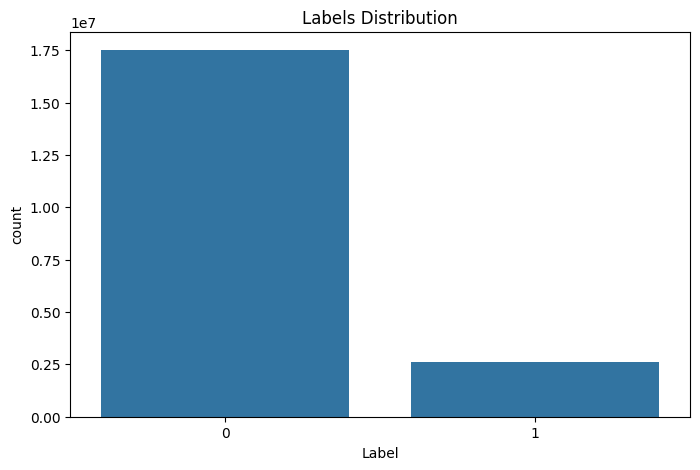

In [6]:
# Plot labels distribution

plt.figure(figsize=(8,5))
sns.countplot(x='Label', data=dataset)
plt.title('Labels Distribution')
plt.show()

The dataset is unbalanced

In [7]:
# Obtain feature with variance zero 
numerical_dataset = dataset.select_dtypes(include=['number'])

# Print features that are not numerical
non_numerical_features = dataset.select_dtypes(exclude=['number']).columns
print("Non-numerical features:", list(non_numerical_features))


zero_variance_features = [col for col in numerical_dataset.columns if numerical_dataset[col].var() == 0]
print("Features with zero variance:", zero_variance_features)

Non-numerical features: ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack']
Features with zero variance: ['FTP_COMMAND_RET_CODE']


In [8]:
# Obtain most important features using RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Remove rows with null values
dataset_importance = dataset.dropna()

# Remove rows with infinite values
dataset_importance = dataset_importance.replace([float('inf'), float('-inf')], pd.NA).dropna()


if FEATURE_IMPORTANCE_PARTIAL:
    N_SAMPLES = 1_000_000

    dataset_importance = (
        dataset_importance
        .groupby('Label', group_keys=False)
        .apply(lambda x: x.sample(
            n=min(len(x), int(N_SAMPLES * len(x) / len(dataset_importance))),
            random_state=42
        ))
    )


X = dataset_importance.drop(columns=['Label', 'Attack', 'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'IPV4_DST_ADDR'])
y = dataset_importance['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)



/tmp/ipykernel_3841063/2559100494.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


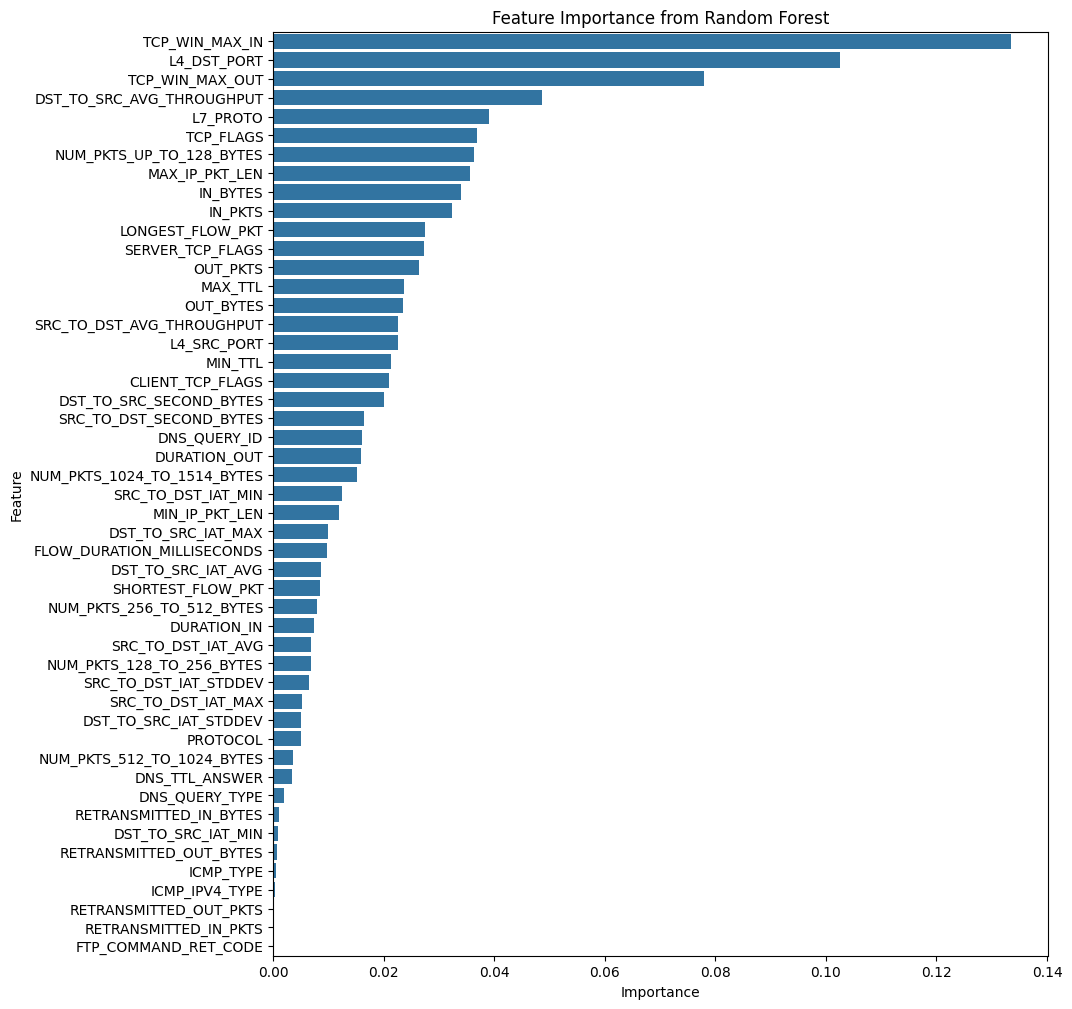

In [9]:
plt.figure(figsize=(10,12))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest')
plt.show()

In [10]:
# Obtain top 15 features
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)
print("Top 15 important features:")
print(top_15_features)


Top 15 important features:
                      Feature  Importance
33             TCP_WIN_MAX_IN    0.133553
1                 L4_DST_PORT    0.102527
34            TCP_WIN_MAX_OUT    0.077864
27  DST_TO_SRC_AVG_THROUGHPUT    0.048712
3                    L7_PROTO    0.038979
8                   TCP_FLAGS    0.036862
28   NUM_PKTS_UP_TO_128_BYTES    0.036244
19             MAX_IP_PKT_LEN    0.035635
4                    IN_BYTES    0.033958
5                     IN_PKTS    0.032381
16           LONGEST_FLOW_PKT    0.027518
10           SERVER_TCP_FLAGS    0.027193
7                    OUT_PKTS    0.026439
15                    MAX_TTL    0.023678
6                   OUT_BYTES    0.023554


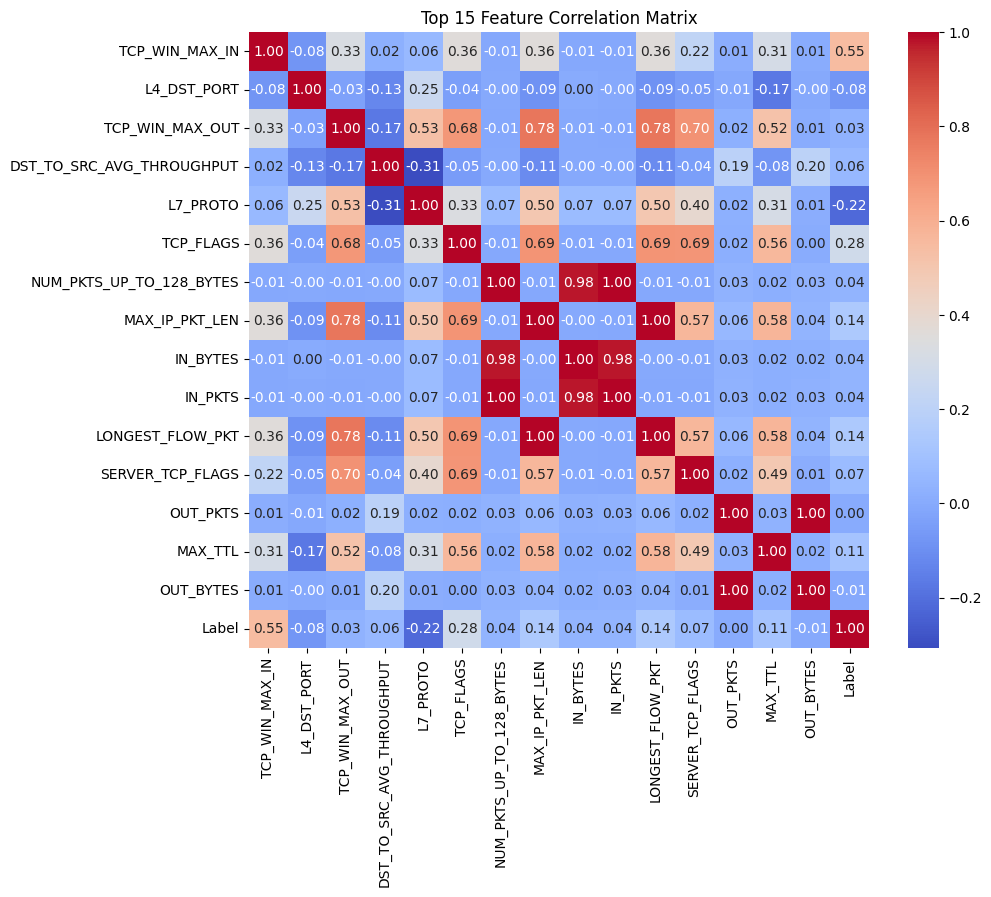

In [11]:
# Matrix correlation of top 15 features and label
plt.figure(figsize=(10,8))
top_features = top_15_features['Feature'].tolist() + ['Label']
correlation_matrix_top = dataset[top_features].corr()
sns.heatmap(correlation_matrix_top, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Top 15 Feature Correlation Matrix')
plt.show()

## Preprocessing

In [ ]:
# Delete null and infinite values from the original dataset
dataset = dataset.replace([float('inf'), float('-inf')], pd.NA).dropna()

# Detelete features with zero variance 
dataset = dataset.drop(columns=zero_variance_features)

# Create bags
dataset['FLOW_START_MILLISECONDS'] = pd.to_datetime(dataset['FLOW_START_MILLISECONDS'], unit='ms')
dataset['FLOW_END_MILLISECONDS'] = pd.to_datetime(dataset['FLOW_END_MILLISECONDS'], unit='ms')

dataset['Hour'] = dataset['FLOW_START_MILLISECONDS'].dt.hour
dataset['Day'] = dataset['FLOW_START_MILLISECONDS'].dt.day
dataset['Minute'] = dataset['FLOW_START_MILLISECONDS'].dt.minute
bags = {}

# Variable to group by number of flows
FLOWS_PER_BAG = 1000

# Sort dataset by time to maintain temporal order
dataset_sorted = dataset.sort_values('FLOW_START_MILLISECONDS').reset_index(drop=True)

# Create bags with fixed number of flows
num_bags = len(dataset_sorted) // FLOWS_PER_BAG

for i in range(num_bags):
    start_idx = i * FLOWS_PER_BAG
    end_idx = start_idx + FLOWS_PER_BAG
    bag_data = dataset_sorted.iloc[start_idx:end_idx]
    
    if not bag_data.empty:
        bag_key = f"Bag_{i:06d}"
        bags[bag_key] = bag_data

# Handle remaining flows (if any)
# remaining_flows = len(dataset_sorted) % FLOWS_PER_BAG
# if remaining_flows > 0:
#     bag_data = dataset_sorted.iloc[-remaining_flows:]
#     bag_key = f"Bag_{num_bags:06d}_partial"
#     bags[bag_key] = bag_data

print(f"Total bags created: {len(bags)}")

# IMPORTANTE: Verificar qué features del top 15 realmente existen en dataset limpio
print("\n--- Verificación de features ---")
print(f"Features en top_15_features: {top_15_features['Feature'].tolist()}")
print(f"Columnas disponibles en dataset: {dataset.columns.tolist()}")

# Filtrar solo las features que existen
available_features = set(dataset.columns)
selected_features = [f for f in top_15_features['Feature'].tolist() if f in available_features]
# # Drop MAX_TTL and MIN_TTL because they have a strong correlation with Label
# selected_features = [f for f in selected_features if f not in ['MAX_TTL', 'MIN_TTL']]
selected_features.append('Label')


print(f"\nFeatures seleccionadas finales: {len(selected_features)-1} (sin contar Label)")
print(f"Features descartadas: {set(top_15_features['Feature'].tolist()) - set(selected_features)}")

# Use only selected features plus the label in the bags
for bag_key in bags:
    bags[bag_key] = bags[bag_key][selected_features]

# Example: Show the first bag
first_bag_key = list(bags.keys())[0]
print(f"\nFirst bag key: {first_bag_key}")
print(bags[first_bag_key].head())


Total bags created: 20115

--- Verificación de features ---
Features en top_15_features: ['TCP_WIN_MAX_IN', 'L4_DST_PORT', 'TCP_WIN_MAX_OUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'L7_PROTO', 'TCP_FLAGS', 'NUM_PKTS_UP_TO_128_BYTES', 'MAX_IP_PKT_LEN', 'IN_BYTES', 'IN_PKTS', 'LONGEST_FLOW_PKT', 'SERVER_TCP_FLAGS', 'OUT_PKTS', 'MAX_TTL', 'OUT_BYTES']
Columnas disponibles en dataset: ['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKT


Number of anomalies per bag (first 10 bags):
Bag_000000: 0 anomalies
Bag_000001: 0 anomalies
Bag_000002: 0 anomalies
Bag_000003: 0 anomalies
Bag_000004: 0 anomalies
Bag_000005: 0 anomalies
Bag_000006: 0 anomalies
Bag_000007: 0 anomalies
Bag_000008: 0 anomalies
Bag_000009: 0 anomalies


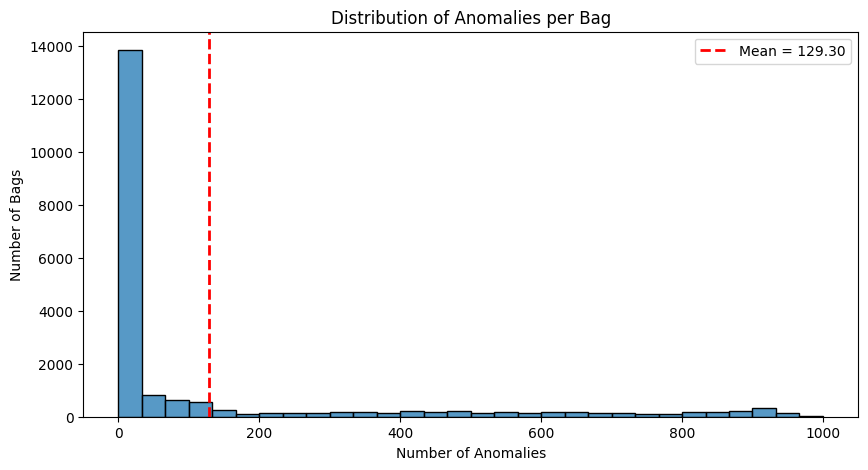

In [13]:
# Calculate number of anomalies per bag
anomalies_per_bag = {}
for bag_key, bag_data in bags.items():
    num_anomalies = bag_data['Label'].sum()
    anomalies_per_bag[bag_key] = num_anomalies

print("\nNumber of anomalies per bag (first 10 bags):")
for bag_key in list(bags.keys())[:10]:
    print(f"{bag_key}: {anomalies_per_bag[bag_key]} anomalies")

# Compute mean
mean_anomalies = np.mean(list(anomalies_per_bag.values()))

# Plot distribution of anomalies per bag
plt.figure(figsize=(10,5))
sns.histplot(list(anomalies_per_bag.values()), bins=30, kde=False)

# Add mean line
plt.axvline(
    mean_anomalies,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_anomalies:.2f}'
)

plt.title('Distribution of Anomalies per Bag')
plt.xlabel('Number of Anomalies')
plt.ylabel('Number of Bags')
plt.legend()
plt.show()


## Deep Sets

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [14]:
# ----------------------------
# Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_STATE = 42
BAG_SIZE = 1000
BATCH_SIZE = 128          # con 14k bags, 128 suele ir bien
EPOCHS = 125
LR = 1e-3
PATIENCE = 7
TOPK = 20                 # top-k pooling (5 o 10)

feature_cols = [c for c in selected_features if c != "Label"]
D = len(feature_cols)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [15]:
# ----------------------------
# 1) dict -> tensor (filtrando tamaño fijo)
# ----------------------------

X_list, y_list = [], []
for k, df in bags.items():
    if len(df) != BAG_SIZE:
        continue
    X_list.append(df[feature_cols].to_numpy(dtype=np.float32))
    y_list.append(int(df["Label"].max()))

X = np.stack(X_list, axis=0)     # (BAGS, 1000, D)
y = np.array(y_list, dtype=np.float32)  # float para BCE

print("X:", X.shape, "y:", y.shape, "pos:", int(y.sum()))

X: (20115, 1000, 15) y: (20115,) pos: 10122


In [19]:
# Print number of benign and malicious samples
print('Benign samples:', int((y == 0).sum()))
print('Malicious samples:', int((y == 1).sum()))

Benign samples: 9993
Malicious samples: 10122


In [16]:
# ----------------------------
# 2) split train/val/test por bag (estratificado)
# ----------------------------

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
idx_tr, idx_va = train_test_split(idx_tr, test_size=0.20, random_state=RANDOM_STATE, stratify=y[idx_tr])  # 64/16/20

Xtr, Xva, Xte = X[idx_tr], X[idx_va], X[idx_te]
ytr, yva, yte = y[idx_tr], y[idx_va], y[idx_te]

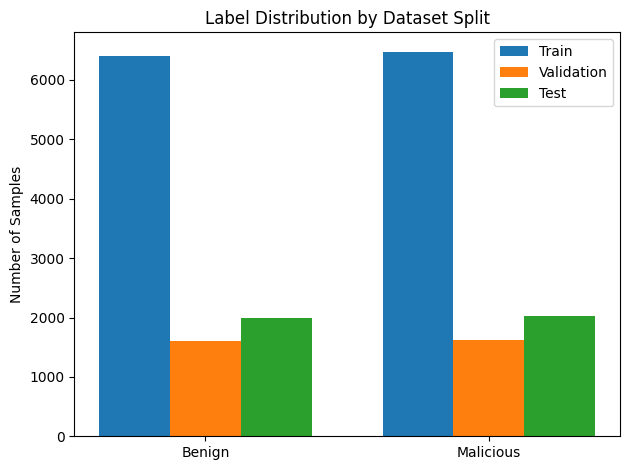

Train samples: 12873 (Benign: 6395, Malicious: 6478)
Validation samples: 3219 (Benign: 1599, Malicious: 1620)
Test samples: 4023 (Benign: 1999, Malicious: 2024)


In [17]:
# PLot label distribution in train, val, test
import matplotlib.pyplot as plt

labels = ['Benign', 'Malicious']
train_counts = [len(ytr) - int(ytr.sum()), int(ytr.sum())]
val_counts = [len(yva) - int(yva.sum()), int(yva.sum())]
test_counts = [len(yte) - int(yte.sum()), int(yte.sum())]

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots()
rects1 = ax.bar(x - width, train_counts, width, label='Train')
rects2 = ax.bar(x, val_counts, width, label='Validation')
rects3 = ax.bar(x + width, test_counts, width, label='Test')    
ax.set_ylabel('Number of Samples')
ax.set_title('Label Distribution by Dataset Split')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
fig.tight_layout()
plt.show()

# Print numbers Train, Validation, Test
print(f"Train samples: {len(ytr)} (Benign: {train_counts[0]}, Malicious: {train_counts[1]})")
print(f"Validation samples: {len(yva)} (Benign: {val_counts[0]}, Malicious: {val_counts[1]})")
print(f"Test samples: {len(yte)} (Benign: {test_counts[0]}, Malicious: {test_counts[1]})")

In [57]:
# ----------------------------
# 3) normalización por feature (fit solo en train)
# ----------------------------
mu = Xtr.reshape(-1, D).mean(axis=0)
sigma = Xtr.reshape(-1, D).std(axis=0) + 1e-8

Xtr = (Xtr - mu) / sigma
Xva = (Xva - mu) / sigma
Xte = (Xte - mu) / sigma


In [58]:
# ----------------------------
# 4) Dataset
# ----------------------------
class BagDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(BagDataset(Xtr, ytr), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(BagDataset(Xva, yva), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(BagDataset(Xte, yte), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [59]:
# ----------------------------
# 5) DeepSets con top-k pooling
# ----------------------------

class DeepSetsTopK(nn.Module):
    def __init__(self, d_in, d_hidden=128, d_latent=64, dropout=0.15, topk=10):
        super().__init__()
        self.topk = topk
        self.phi = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_latent),
            nn.ReLU()
        )
        # usamos mean + topk_mean (2*latent)
        self.rho = nn.Sequential(
            nn.Linear(2 * d_latent, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1)  # logit binario
        )

    def forward(self, x):
        # x: (B, N, D)
        z = self.phi(x)  # (B, N, L)
        z_mean = z.mean(dim=1)  # (B, L)

        k = min(self.topk, z.size(1))
        # top-k por dimension latente (MIL-friendly)
        z_topk, _ = torch.topk(z, k=k, dim=1, largest=True, sorted=False)  # (B, k, L)
        z_topk_mean = z_topk.mean(dim=1)  # (B, L)

        z_bag = torch.cat([z_mean, z_topk_mean], dim=1)  # (B, 2L)
        logit = self.rho(z_bag).squeeze(1)  # (B,)
        return logit

model = DeepSetsTopK(d_in=D, d_hidden=128, d_latent=64, dropout=0.15, topk=TOPK).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [60]:
# ----------------------------
# 6) Train con early stopping por F1 en VALIDACIÓN
# ----------------------------
def eval_loader(loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logit = model(xb)
            prob = torch.sigmoid(logit).cpu().numpy()
            ys.append(yb.numpy())
            ps.append(prob)
    y_true = np.concatenate(ys).astype(int)
    prob = np.concatenate(ps)
    y_pred = (prob >= 0.5).astype(int)
    return y_true, y_pred, prob

best_f1 = -1.0
best_state = None
bad_epochs = 0
train_losses = []
total_epochs = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    total_epochs += 1

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logit = model(xb)
        loss = criterion(logit, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    yv_true, yv_pred, _ = eval_loader(val_loader)
    f1v = f1_score(yv_true, yv_pred)

    print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | val F1 {f1v:.4f}")

    if f1v > best_f1 + 1e-4:
        best_f1 = f1v
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping (best val F1={best_f1:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)



Epoch 01 | loss 0.5329 | val F1 0.7870
Epoch 02 | loss 0.3867 | val F1 0.8000
Epoch 03 | loss 0.3548 | val F1 0.8253
Epoch 04 | loss 0.3227 | val F1 0.8422
Epoch 05 | loss 0.2940 | val F1 0.8411
Epoch 06 | loss 0.2869 | val F1 0.8772
Epoch 07 | loss 0.2640 | val F1 0.8800
Epoch 08 | loss 0.2609 | val F1 0.8855
Epoch 09 | loss 0.2615 | val F1 0.8731
Epoch 10 | loss 0.2591 | val F1 0.8859
Epoch 11 | loss 0.2502 | val F1 0.8821
Epoch 12 | loss 0.2515 | val F1 0.8888
Epoch 13 | loss 0.2507 | val F1 0.8843
Epoch 14 | loss 0.2447 | val F1 0.8824
Epoch 15 | loss 0.2402 | val F1 0.8901
Epoch 16 | loss 0.2400 | val F1 0.8900
Epoch 17 | loss 0.2339 | val F1 0.8824
Epoch 18 | loss 0.2355 | val F1 0.8879
Epoch 19 | loss 0.2338 | val F1 0.8957
Epoch 20 | loss 0.2289 | val F1 0.8964
Epoch 21 | loss 0.2275 | val F1 0.8887
Epoch 22 | loss 0.2233 | val F1 0.8974
Epoch 23 | loss 0.2203 | val F1 0.9027
Epoch 24 | loss 0.2171 | val F1 0.9019
Epoch 25 | loss 0.2129 | val F1 0.9020
Epoch 26 | loss 0.2115 | 

In [61]:
# ----------------------------
# 7) Test final
# ----------------------------
yt_true, yt_pred, yt_prob = eval_loader(test_loader)
print("\nDeepSetsTopK Report:\n", classification_report(yt_true, yt_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(yt_true, yt_pred))



DeepSetsTopK Report:
               precision    recall  f1-score   support

           0     0.9646    0.9550    0.9598      1999
           1     0.9560    0.9654    0.9607      2024

    accuracy                         0.9602      4023
   macro avg     0.9603    0.9602    0.9602      4023
weighted avg     0.9603    0.9602    0.9602      4023

Confusion matrix:
 [[1909   90]
 [  70 1954]]


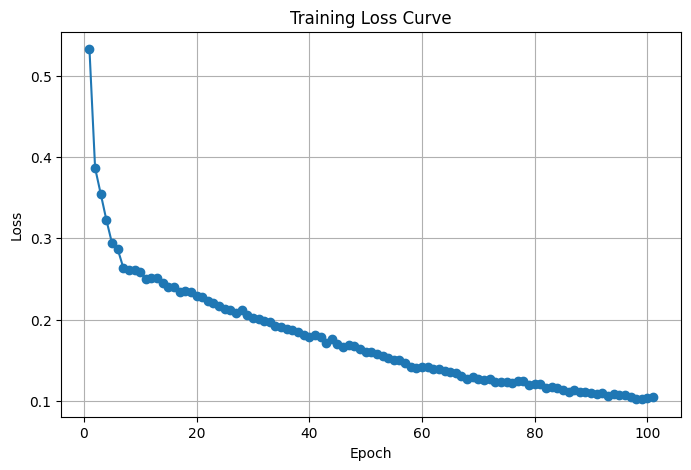

In [62]:
# Plot training loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1, total_epochs+1), train_losses, marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()

In [ ]:
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# ----------------------------
# Dataset / Loader helpers
# ----------------------------
class BagDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def make_loaders(Xtr, ytr, Xva, yva, Xte, yte, batch_size):
    train_loader = DataLoader(BagDataset(Xtr, ytr), batch_size=batch_size, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(BagDataset(Xva, yva), batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader  = DataLoader(BagDataset(Xte, yte), batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader, test_loader

# ----------------------------
# Model (tu DeepSetsTopK)
# ----------------------------
class DeepSetsTopK(nn.Module):
    def __init__(self, d_in, d_hidden=128, d_latent=64, dropout=0.15, topk=10):
        super().__init__()
        self.topk = topk
        self.phi = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_latent),
            nn.ReLU()
        )
        self.rho = nn.Sequential(
            nn.Linear(2 * d_latent, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1)
        )

    def forward(self, x):
        z = self.phi(x)                 # (B, N, L)
        z_mean = z.mean(dim=1)          # (B, L)
        k = min(self.topk, z.size(1))
        z_topk, _ = torch.topk(z, k=k, dim=1, largest=True, sorted=False)  # (B, k, L)
        z_topk_mean = z_topk.mean(dim=1)                                  # (B, L)
        z_bag = torch.cat([z_mean, z_topk_mean], dim=1)                    # (B, 2L)
        logit = self.rho(z_bag).squeeze(1)                                 # (B,)
        return logit

# ----------------------------
# Eval: devuelve probas + best threshold para F1
# ----------------------------
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logit = model(xb)
        prob = torch.sigmoid(logit).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(prob)
    y_true = np.concatenate(ys).astype(int)
    prob = np.concatenate(ps)
    return y_true, prob

def best_f1_threshold(y_true, prob, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)  # 0.05,0.10,...,0.95
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        y_pred = (prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_f1, best_t

# ----------------------------
# Train 1 run con early stopping por F1(val) (con threshold tuning)
# ----------------------------
def run_one_config(
    Xtr, ytr, Xva, yva, Xte, yte, D, DEVICE,
    params,
    epochs=80,
    patience=7,
    seed=42,
):
    # Repro
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_loader, val_loader, test_loader = make_loaders(
        Xtr, ytr, Xva, yva, Xte, yte, batch_size=params["batch_size"]
    )

    model = DeepSetsTopK(
        d_in=D,
        d_hidden=params["d_hidden"],
        d_latent=params["d_latent"],
        dropout=params["dropout"],
        topk=params["topk"],
    ).to(DEVICE)

    # (Opcional) pos_weight para desbalanceo: pos_weight = n_neg/n_pos
    # Si lo quieres meter en grid, añádelo como params["use_pos_weight"] o params["pos_weight"]
    if params.get("use_pos_weight", False):
        n_pos = float(ytr.sum())
        n_neg = float(len(ytr) - ytr.sum())
        pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], device=DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    best_state = None
    best_val_f1 = -1.0
    best_val_thr = 0.5
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logit = model(xb)
            loss = criterion(logit, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=params["grad_clip"])
            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        avg_loss = total_loss / len(train_loader.dataset)

        # Val: proba + threshold tuning
        yv_true, yv_prob = predict_proba(model, val_loader, DEVICE)
        val_f1, val_thr = best_f1_threshold(yv_true, yv_prob)

        # Early stopping
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_val_thr = val_thr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    # Load best
    if best_state is not None:
        model.load_state_dict(best_state)

    # Test con el threshold elegido en val
    yt_true, yt_prob = predict_proba(model, test_loader, DEVICE)
    yt_pred = (yt_prob >= best_val_thr).astype(int)
    test_f1 = f1_score(yt_true, yt_pred)

    return {
        "val_f1": best_val_f1,
        "val_thr": best_val_thr,
        "test_f1": test_f1,
        "model_state": best_state,
    }

# ----------------------------
# GRID SEARCH
# ----------------------------
param_grid = {
    "d_hidden":     [64, 128, 256],
    "d_latent":     [32, 64, 128],
    "dropout":      [0.0, 0.15, 0.30],
    "topk":         [5, 10, 20],
    "lr":           [3e-4, 1e-3, 3e-3],
    "weight_decay": [0.0, 1e-4, 1e-3],
    "batch_size":   [64, 128],
    "grad_clip":    [1.0],          # puedes probar 0.5 / 2.0 si quieres
    # "use_pos_weight": [False, True],  # si hay mucho desbalanceo, actívalo
}

# Para que no explote el nº de combinaciones, puedes limitar:
MAX_RUNS = 700  # sube/baja a tu gusto
EPOCHS_GS = 60
PATIENCE_GS = 7

keys = list(param_grid.keys())
all_combos = list(itertools.product(*[param_grid[k] for k in keys]))

print(f"Total combinations: {len(all_combos)}")

# Barajamos para explorar diversidad si cortas a MAX_RUNS
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(all_combos)

results = []
best_overall = {"val_f1": -1.0}

for i, combo in enumerate(all_combos[:MAX_RUNS], start=1):
    print(f"\n=== RUN {i}/{min(MAX_RUNS,len(all_combos))} ===")
    params = dict(zip(keys, combo))

    # Limpieza GPU entre runs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    out = run_one_config(
        Xtr, ytr, Xva, yva, Xte, yte,
        D=D,
        DEVICE=DEVICE,
        params=params,
        epochs=EPOCHS_GS,
        patience=PATIENCE_GS,
        seed=RANDOM_STATE,
    )

    row = {**params, **{k: out[k] for k in ["val_f1", "val_thr", "test_f1"]}}
    results.append(row)

    if out["val_f1"] > best_overall["val_f1"]:
        best_overall = {"val_f1": out["val_f1"], "params": params, "val_thr": out["val_thr"], "state": out["model_state"]}

    print(f"[{i:02d}/{min(MAX_RUNS,len(all_combos))}] "
          f"val_f1={out['val_f1']:.4f} (thr={out['val_thr']:.2f}) | "
          f"test_f1={out['test_f1']:.4f} | params={params}")

df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
print("\nTOP configs by val_f1:")
print(df.head(10))

print("\nBest overall:")
print(best_overall["params"], "val_f1=", best_overall["val_f1"], "thr=", best_overall["val_thr"])

# ----------------------------
# (Opcional) Evaluación final detallada en TEST con el mejor estado
# ----------------------------
best_params = best_overall["params"]
best_state  = best_overall["state"]
best_thr    = best_overall["val_thr"]

# Reconstruye el modelo best y evalúa con report completo
best_model = DeepSetsTopK(
    d_in=D,
    d_hidden=best_params["d_hidden"],
    d_latent=best_params["d_latent"],
    dropout=best_params["dropout"],
    topk=best_params["topk"],
).to(DEVICE)
best_model.load_state_dict(best_state)

_, _, test_loader = make_loaders(Xtr, ytr, Xva, yva, Xte, yte, batch_size=best_params["batch_size"])

yt_true, yt_prob = predict_proba(best_model, test_loader, DEVICE)
yt_pred = (yt_prob >= best_thr).astype(int)

print("\nBest DeepSetsTopK TEST report (threshold tuned on VAL):")
print(classification_report(yt_true, yt_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(yt_true, yt_pred))
